In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

#data preprocessing
df = pd.read_csv("/content/data.csv")
target_col = "Restormel 10SRE01"
time_features = ["hour", "day_of_week", "month", "day", "is_weekend"]
all_features = [target_col] + time_features

df = df[all_features]
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.values)
data = pd.DataFrame(df_scaled, columns=df.columns)
data.index = pd.date_range("2024-01-01", periods=len(data), freq="h")
data.index.name = "datetime"

#Sequence Prep
def create_sequences(data, target_col, seq_len, label_len):
    X_enc, X_dec, Y = [], [], []
    for i in range(len(data) - seq_len - label_len):
        enc = data.iloc[i:i+seq_len].values
        dec = data.iloc[i+seq_len:i+seq_len+label_len].values
        label = data.iloc[i+seq_len:i+seq_len+label_len][target_col].values.reshape(-1, 1)
        X_enc.append(enc)
        X_dec.append(dec)
        Y.append(label)
    return np.array(X_enc), np.array(X_dec), np.array(Y)

seq_len = 504
label_len = 672
pred_len = 1344
X_enc, X_dec, Y = create_sequences(data, target_col, seq_len, label_len)

#Train/Test Split
split = int(len(X_enc) * 0.8)
X_train_enc, X_test_enc = X_enc[:split], X_enc[split:]
X_train_dec, X_test_dec = X_dec[:split], X_dec[split:]
Y_train, Y_test = Y[:split], Y[split:]

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import numpy as np


class SinusoidalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pos_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.2):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_ff, activation='relu'),
            layers.Dense(d_model)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=True):
        x = self.norm1(x + self.dropout(self.attn(x, x), training=training))
        return self.norm2(x + self.dropout(self.ffn(x), training=training))

class TransformerDecoderBlock(layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)
        self.cross_attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_ff, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
            layers.Dense(d_model, kernel_regularizer=regularizers.l2(1e-4))
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.norm3 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, enc_output, training=True):
        x = self.norm1(x + self.dropout(self.self_attn(x, x), training=training))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_output), training=training))
        return self.norm3(x + self.dropout(self.ffn(x), training=training))

class SimpleInformer(tf.keras.Model):
    def __init__(self, input_dim, d_model=256, n_heads=8, d_ff=1024, dropout=0.1,
                 seq_len=168, label_len=72, pred_len=672):
        super().__init__()
        self.pred_len = pred_len
        self.label_len = label_len
        self.seq_len = seq_len

        self.input_proj = layers.Dense(d_model)
        self.pos_enc = SinusoidalEncoding(d_model)

        self.encoder_blocks = [TransformerEncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(2)]
        self.decoder_blocks = [TransformerDecoderBlock(d_model, n_heads, d_ff, dropout)]

        self.output_proj = layers.Dense(1)

    def call(self, inputs, training=True):
        enc_input, dec_input = inputs

        enc = self.pos_enc(self.input_proj(enc_input))
        for block in self.encoder_blocks:
            enc = block(enc, training=training)

        dec = self.pos_enc(self.input_proj(dec_input))
        for block in self.decoder_blocks:
            dec = block(dec, enc, training=training)

        return self.output_proj(dec[:, -self.pred_len:, :])  # output last `pred_len` steps


In [3]:
from tensorflow.keras.callbacks import EarlyStopping

#instantiate model
model = SimpleInformer(
    input_dim=data.shape[1],
    seq_len=1008,
    label_len=1344,
    pred_len=1344
)

#compile
model.compile(optimizer='adam', loss='mse')

#fit
model.fit(
    (X_train_enc, X_train_dec), Y_train,
    validation_data=((X_test_enc, X_test_dec), Y_test),
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 162s 459ms/step - loss: 5.1001 - val_loss: 0.0860
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.1003 - val_loss: 0.0823
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0893 - val_loss: 0.0797
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0843 - val_loss: 0.0775
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0807 - val_loss: 0.0747
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0772 - val_loss: 0.0720
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0758 - val_loss: 0.0710
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0716 - val_loss: 0.0661
Epoch 9/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0719 - val_loss: 0.0644
Epoch 10/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0645 - val_loss: 0.0608
Epoch 11/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - loss: 0.0613 - val_loss: 0.0592
Epoch 12/20
191/191 ━━━━━━━━

48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step
MAE: 0.2239
MSE: 0.0996
R² Score: 0.9994


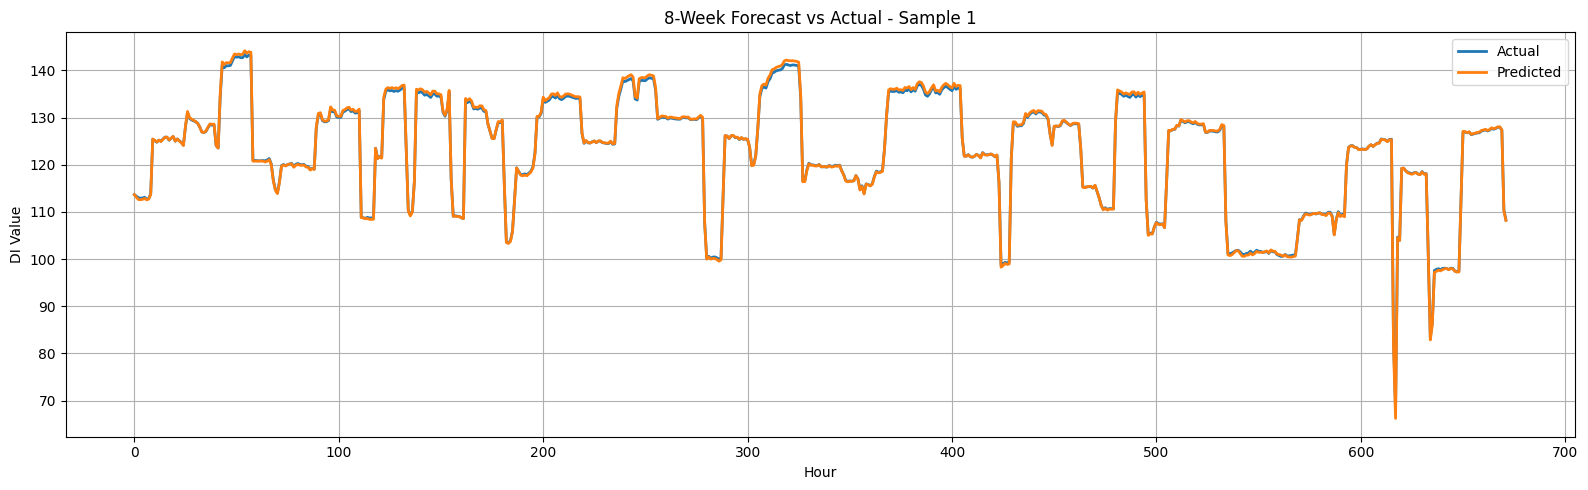

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# predictions
Y_pred_scaled = model.predict((X_test_enc, X_test_dec))

#inverse
target_index = data.columns.get_loc(target_col)

#for inverse scaled predictions and true values
Y_pred_inv = []
Y_true_inv = []

for y_pred_seq, y_true_seq in zip(Y_pred_scaled, Y_test):

    dummy_row = np.zeros(data.shape[1])


    pred_rows = []
    true_rows = []

    for val in y_pred_seq:
        dummy_row[target_index] = val[0]
        inv = scaler.inverse_transform([dummy_row])[0][target_index]
        pred_rows.append(inv)

    for val in y_true_seq:
        dummy_row[target_index] = val[0]
        inv = scaler.inverse_transform([dummy_row])[0][target_index]
        true_rows.append(inv)

    Y_pred_inv.append(pred_rows)
    Y_true_inv.append(true_rows)

Y_pred_inv = np.array(Y_pred_inv)
Y_true_inv = np.array(Y_true_inv)

Y_pred_flat = Y_pred_inv.flatten()
Y_true_flat = Y_true_inv.flatten()

mae = mean_absolute_error(Y_true_flat, Y_pred_flat)
mse = mean_squared_error(Y_true_flat, Y_pred_flat)
r2 = r2_score(Y_true_flat, Y_pred_flat)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# predictions vs actuals plot
plt.figure(figsize=(16, 5))
plt.plot(Y_true_inv[0], label="Actual", linewidth=2)
plt.plot(Y_pred_inv[0], label="Predicted", linewidth=2)
plt.title("8-Week Forecast vs Actual - Sample 1")
plt.xlabel("Hour")
plt.ylabel("DI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
def predict_mc_dropout(model, enc_input, dec_input, n_iter=50):
    preds = []

    for _ in range(n_iter):
        pred = model((enc_input, dec_input), training=True)
        preds.append(pred.numpy())

    preds = np.stack(preds, axis=0)

    mean_pred = preds.mean(axis=0).squeeze()
    std_pred = preds.std(axis=0).squeeze()

    lower_bound = mean_pred - 1.96 * std_pred
    upper_bound = mean_pred + 1.96 * std_pred

    return mean_pred, lower_bound, upper_bound

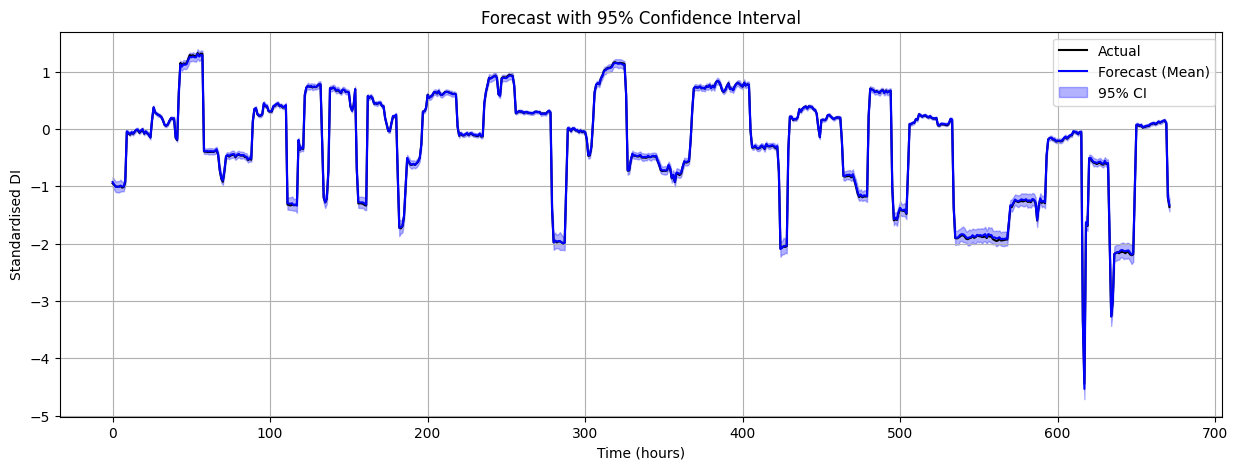

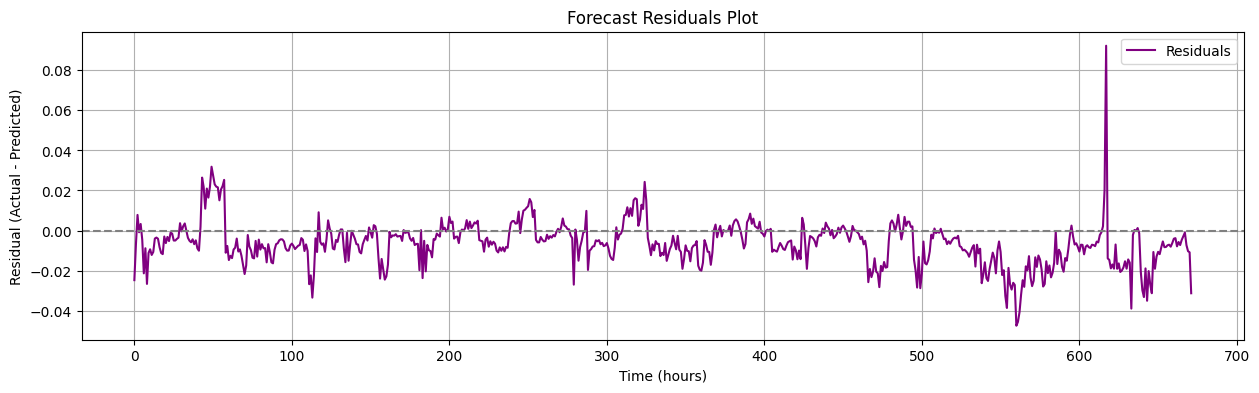

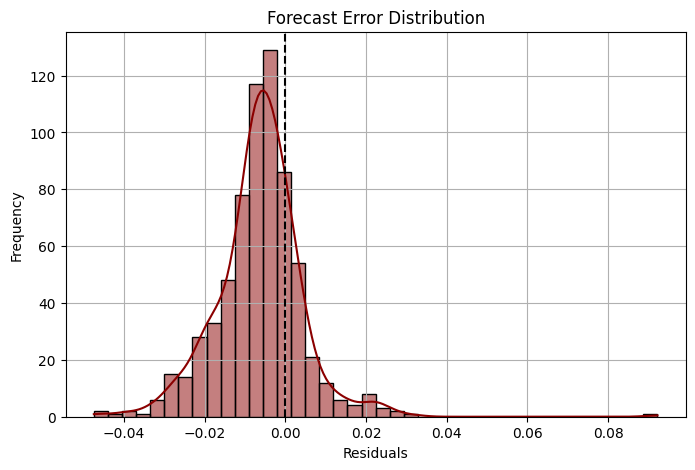

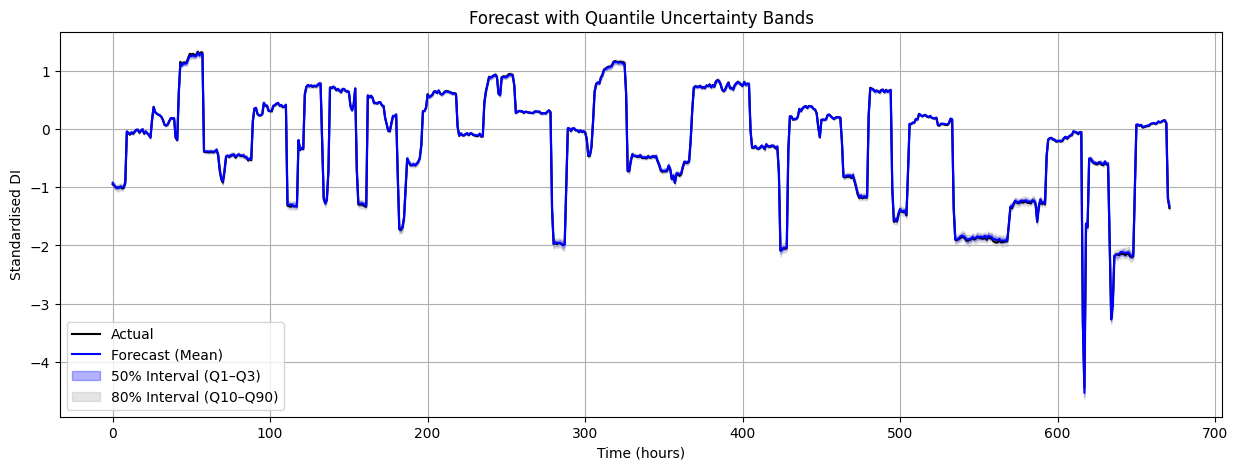

Evaluation Metrics:
R² Score: 0.9998
MAE: 0.0094
MSE: 0.0002


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mean_pred, lower_bound, upper_bound = predict_mc_dropout(model, X_test_enc[0:1], X_test_dec[0:1], n_iter=100)

#targets
true_y = Y_test[0].squeeze()

#Residuals Over Time
residuals = true_y - mean_pred
plt.figure(figsize=(15, 4))
plt.plot(residuals, label='Residuals', color='purple')
plt.axhline(0, linestyle='--', color='gray')
plt.title("Forecast Residuals Plot")
plt.xlabel("Time (hours)")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True)
plt.legend()
plt.show()

#Forecast Error Distribution
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True, color='darkred')
plt.axvline(0, color='black', linestyle='--')
plt.title("Forecast Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()





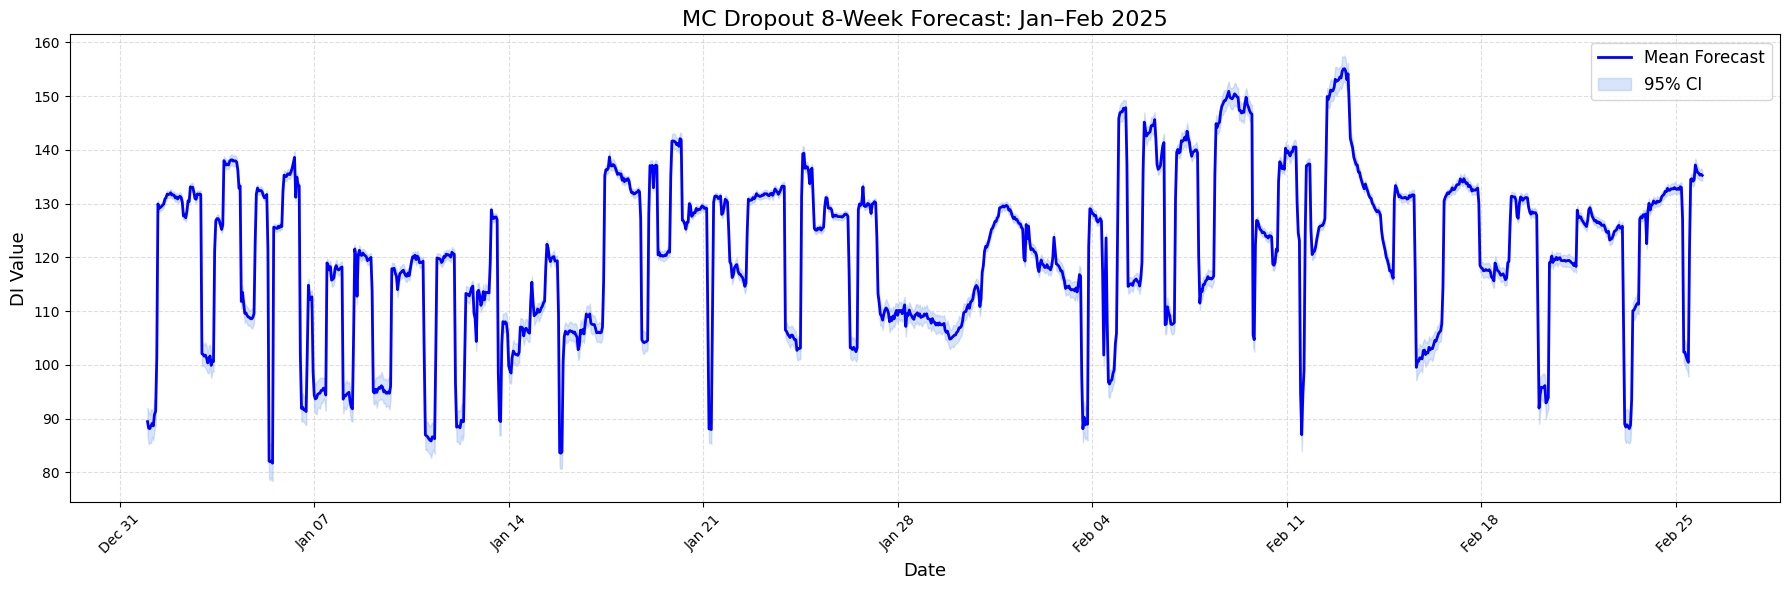

In [183]:
plt.figure(figsize=(18, 6))

# Plot mean forecast and 95% CI
plt.plot(forecast_dates, forecast_2025, label="Mean Forecast", color="blue", linewidth=2)
plt.fill_between(forecast_dates, lower_2025, upper_2025, color="cornflowerblue", alpha=0.25, label="95% CI")

# Title and axis labels
plt.title("MC Dropout 8-Week Forecast: Jan–Feb 2025", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("DI Value", fontsize=13)

# Format x-axis as dates with rotation
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

# Add grid lines
plt.grid(True, linestyle="--", alpha=0.4)

# Legend and layout
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()